# Mixture of Regressions

In this lab, we shall go over a simple application of mixture modeling to regression problems. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az


Consider the following simulated regression dataset $(x_1, y_1), \dots, (x_n, y_n)$. 

In [2]:
rng = np.random.default_rng(seed = 123)

n = 400
sigma = 0.5

beta_vals = np.array([[3.0, -1.0], [1.0, 1.5], [-1.0, 0.5]])
print(beta_vals)
probs = np.array([0.3, 0.3, 0.4])

#sample x_i \sim uniform(-1, 3)
x = rng.uniform(-1, 3, size = n)

#sample component labels
z = rng.choice(3, size = n, p = probs)

#assign coefficients: 
beta0 = beta_vals[z, 0]
beta1 = beta_vals[z, 1]

#sample noise: 
eps = rng.normal(0, sigma, size = n)

#generate y_i
y = beta0 + beta1 * x + eps

#store as data: 
data = pd.DataFrame({'x': x, 'y': y})
display(data.head())

[[ 3.  -1. ]
 [ 1.   1.5]
 [-1.   0.5]]


,x,y
0,1.729407,3.977898
1,-0.784716,4.211973
2,-0.118561,0.715021
3,-0.262513,0.619291
4,-0.296376,-2.033803


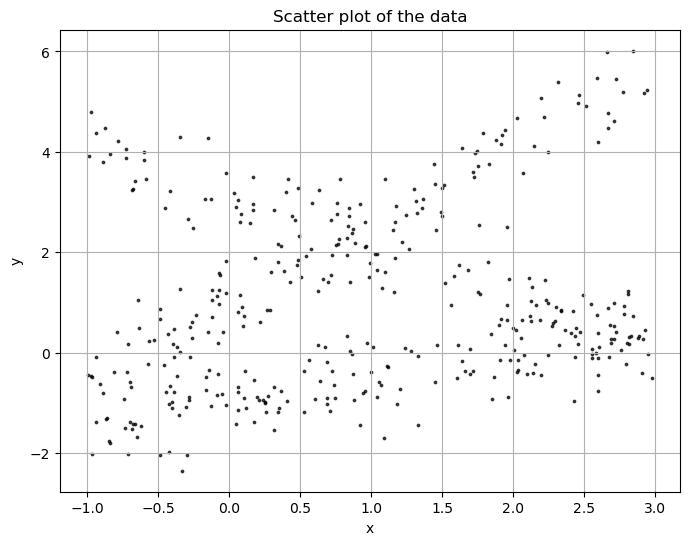

In [ ]:
#Plot the data: 
plt.figure(figsize = (8, 6))
plt.scatter(x, y, alpha = 0.7, s = 3, color = 'black')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of the data')
plt.grid(True)
plt.show()

This regression dataset was generated from a **mixture of three linear regression models**. For each observation $i$, the response $y_i$ is produced by taking a linear function of the covariate $x_i$ and then adding independent random noise. The important feature is that the linear relationship is **not the same across all observations**. Instead, each data point comes from one of three possible linear models.

The three underlying linear functions correspond to the coefficient pairs $(3,-1), (1,1.5)$ and $(-1,0.5)$. Thus, for each observation $i$, one of these three pairs is selected at random, with probabilities \(0.3\), \(0.3\), and \(0.4\), respectively. Conditional on this choice, the response $y_i$ is generated according to the corresponding linear model, with an additional independent noise term.

A natural interpretation is that the dataset is drawn from **three hidden subpopulations**. Each subpopulation has its own regression line, but the identity of the subpopulation is not observed directly. As a result, the full dataset is heterogeneous: rather than following a single linear trend, it consists of a blend of three different trends. This is precisely the setting of a **mixture of regressions** model, where the goal is often to recover both the underlying regression relationships and the latent population structure.

We will use the following model for this data: 
\begin{align*}
   y_i = \beta_0^i + \beta_1^i x_i + \epsilon_i
\end{align*}
with 
\begin{align*}
   (\beta_0^i, \beta_1^i) \overset{\text{i.i.d}}{\sim} \sum_{j=1}^3 w_j \delta_{(\gamma_0^j, \gamma_1^j)}
\end{align*}
where $(\gamma_0^j, \gamma_1^j), j = 1, 2, 3$ are the three unknown coefficient vectors and $(w_1, w_2, w_3)$ denote the probability weights. Another unknown parameter is the variance $\sigma^2$ of $\epsilon_i$, but we shall assume that this is known for simplicity (in the above simulation example, $\sigma$ is fixed to be $0.5$). 

As the prior, we assume that: 
\begin{align*}
   \gamma_0^1, \gamma_1^1, \gamma_0^2, \gamma_1^2, \gamma_0^3, \gamma_1^3 \overset{\text{i.i.d}}{\sim} N(0, C) 
\end{align*}
for a large constant $C$, along with
\begin{align*}
   (w_1, w_2, w_3) \sim \text{Dirichlet}(1, 1, 1)
\end{align*}

## Gibbs Sampler

To implement the Gibbs sampler in this model, we introduce latent allocation variables $z_1, \dots, z_n$ with each $z_i \in \{1, 2, 3\}$. With these variables, the model can be written as: 
\begin{align*}
   \mathbb{P}\{z_i = j\} = w_j ~~ \text{ for $j = 1, 2, 3$}. 
\end{align*}

\begin{align*}
   y_i \mid z_i = j, \gamma_0^j \gamma_1^j, x_i \sim N(\gamma_0^j + \gamma_1^j x_i, \sigma^2). 
\end{align*}

We will use the Gibbs sampler to simulate from the joint distribution of $(w_1, w_2, w_3, \gamma_0^1, \gamma_1^1, \gamma_0^2, \gamma_1^2, \gamma_0^3, \gamma_1^3, z_1, \dots, z_n)$ given the data $(x_i, y_i), 1 \leq i \leq n$. The conditional distribution of $z_i$ given $w_1, w_2, w_3, \gamma_0^1, \gamma_1^1, \gamma_0^2, \gamma_1^2, \gamma_0^3, \gamma_1^3$ and the data is: 
\begin{align*}
   \mathbb{P} \left\{z_i = j \mid \text{data}, w_1, w_2, w_3, \gamma_0^1, \gamma_1^1, \gamma_0^2, \gamma_1^2, \gamma_0^3, \gamma_1^3 \right\} = \frac{w_j \phi(y_i, \gamma_0^j + \gamma_1^j x_i, \sigma)}{\sum_{j=1}^3 w_j \phi(y_i, \gamma_0^j + \gamma_1^j x_i, \sigma)}. 
\end{align*}
In other words, $z_i$ (conditional on $w_1, w_2, w_3, \gamma_0^1, \gamma_1^1, \gamma_0^2, \gamma_1^2, \gamma_0^3, \gamma_1^3$) is discrete taking the values $1, 2, 3$ with probabilities $p_{i1}, p_{i2}, p_{i3}$ with
\begin{align*}
   p_{ij} = \frac{w_j \phi(y_i, \gamma_0^j + \gamma_1^j x_i, \sigma)}{\sum_{j=1}^3 w_j \phi(y_i, \gamma_0^j + \gamma_1^j x_i, \sigma)}. 
\end{align*}
The conditional distribution of $w_1, w_2, w_3$ given $y_1, \dots, y_n, z_1, \dots, z_n$ is: 
\begin{align*}
   (w_1, w_2, w_3) \mid z_1, \dots, z_n \sim \text{Dirichlet}(1 + n_1, 1 + n_2, 1 + n_3)
\end{align*}
where $n_j = \sum_{i=1}^n I\{z_i = j\}$ for $j = 1, 2, 3$. 

For a fixed $j = 1, 2, 3$, the conditional distribution of $\gamma_0^j, \gamma_1^j$ given the data and $z_1, \dots, z_n$ is calculated as follows. First take 
\begin{align*}
   I_j = \left\{i = 1, \dots, n : z_i = j \right\}  ~~ \text{ and } ~~ n_j = |I_j|. 
\end{align*}
Let $X_j$ be the $n_j \times 2$ matrix whose rows are given by $(1, x_i)$ for $i \in I_j$. Also let $Y_j$ be the $n_j \times 1$ vector with entries $y_i, i \in I_j$. Then
\begin{align*}
  \begin{pmatrix} \gamma_0^j \\ \gamma_1^j \end{pmatrix} \mid \text{y, z} \sim N \left( \left(\frac{1}{\sigma^2} X_j^T X_j + \frac{1}{C} I_{2 \times 2}\right)^{-1} \frac{1}{\sigma^2} X_j^T Y_j, \left(\frac{1}{\sigma^2} X_j^T X_j + \frac{1}{C} I_{2 \times 2}\right)^{-1} \right). 
\end{align*}

## Algorithm for the Gibbs Sampler: 

So here is the algorithm for the Gibbs sampler for mixture of linear regression. 

We start with initial values
\begin{align*}
w^{(0)},\gamma^{1,0},\gamma^{2,0},\gamma^{3,0},
\end{align*}
and repeat for $t=1,2,\dots$ as follows.

1. For each $i = 1, \dots, n$, sample
\begin{align*}
   z_i^{(t)} \sim \mathrm{Categorical}\bigl(p_{i1}^{(t)},p_{i2}^{(t)},p_{i3}^{(t)}\bigr),
\end{align*}
where 
\begin{align*}
  p_{ij}^{(t)} \propto w_j^{(t-1)} \,
\phi\!\left(y_i, \gamma_0^{j, t-1} + \gamma_1^{j, t-1} x_i ,\sigma^2\right). 
\end{align*}

2. Compute the counts
\begin{align*}
   n_j^{(t)} = \sum_{i=1}^n \mathbf{1}\{z_i^{(t)} = j\}
\end{align*}
for $j = 1, 2, 3$, and sample
\begin{align*}
   w^{(t)} \sim \mathrm{Dirichlet}\bigl(1+n_1^{(t)},\,1+n_2^{(t)},\,1+n_3^{(t)}\bigr).
\end{align*}

3. For each $j = 1, 2, 3$ using the observations with $z_i^{(t)} = j$, sample
\begin{align*}
   \gamma^{j,t} \sim N\bigl(m_j^{(t)},V_j^{(t)}\bigr),
\end{align*}
where
\begin{align*}
   V_j^{(t)}
=
\left(
\frac{1}{\sigma^2}(X_j^{(t)})^\top X_j^{(t)} + \frac{1}{C}I_2
\right)^{-1}
\end{align*}
and
\begin{align*}
   m_j^{(t)}
=
V_j^{(t)}
\left(
\frac{1}{\sigma^2}(X_j^{(t)})^\top Y_j^{(t)}
\right).
\end{align*}
Here $X_j^{(t)}$ is the $n_j^{(t)} \times 2$ matrix with rows $(1, x_i)$ for $i$ such that $z_i^{(t)} = j$, and $Y_j^{(t)}$ is the $n_j^{(t)} \times 1$ vector with entries $y_i$ for $i$ such that $z_i^{(t)} = j$. 

Below is the code which implements the Gibbs sampler.  

In [3]:
def gibbs_mix3_regression(x, y, sigma=0.5, C=100.0, n_iter=5000, burnin=1000, seed=None):
    rng = np.random.default_rng(seed)

    x = np.asarray(x)
    y = np.asarray(y)
    n = len(y)
    Xfull = np.column_stack([np.ones(n), x])

    # initialize
    z = rng.integers(0, 3, size=n)
    w = np.array([1/3, 1/3, 1/3], dtype=float)
    gamma = rng.normal(0, np.sqrt(C), size=(3, 2))

    w_samples = np.zeros((n_iter - burnin, 3))
    gamma_samples = np.zeros((n_iter - burnin, 3, 2))
    z_samples = np.zeros((n_iter - burnin, n), dtype=int)

    eye2 = np.eye(2)

    for it in range(n_iter):
        # update z
        logp = np.empty((n, 3))
        for j in range(3):
            mean_j = gamma[j, 0] + gamma[j, 1] * x
            logp[:, j] = np.log(w[j]) - 0.5 * (y - mean_j) ** 2 / sigma**2

        logp -= logp.max(axis=1, keepdims=True)
        p = np.exp(logp)
        p /= p.sum(axis=1, keepdims=True)

        u = rng.random(n)
        z = (u[:, None] > np.cumsum(p, axis=1)).sum(axis=1)

        # update w
        counts = np.bincount(z, minlength=3)
        w = rng.dirichlet(1 + counts)

        # update gamma_j
        for j in range(3):
            idx = (z == j)
            Xj = Xfull[idx]
            yj = y[idx]

            V = np.linalg.inv((Xj.T @ Xj) / sigma**2 + eye2 / C)
            m = V @ (Xj.T @ yj) / sigma**2
            gamma[j] = rng.multivariate_normal(m, V)

        if it >= burnin:
            k = it - burnin
            w_samples[k] = w
            gamma_samples[k] = gamma
            z_samples[k] = z

    return {
        "w_samples": w_samples,
        "gamma_samples": gamma_samples,
        "z_samples": z_samples,
    }

In the following code, we use the Gibbs sampler on the simulated data shown above. 

In [4]:
out = gibbs_mix3_regression(x, y, sigma=0.5, C=100.0, n_iter=6000, burnin=1000, seed=1)

Below we compute the posterior means of the parameters $w_1, w_2, w_3$ and $\gamma_0^j, \gamma_1^j$ for $j = 1, 2, 3$. 

In [5]:
w_post_mean = out["w_samples"].mean(axis=0)
gamma_post_mean = out["gamma_samples"].mean(axis=0)

print("posterior mean of w:", w_post_mean)
print("posterior mean of gammas:")
print(gamma_post_mean)

posterior mean of w: [0.27366438 0.41034453 0.31599109]
posterior mean of gammas:
[[ 3.10019646 -1.00922764]
 [-0.96064476  0.47280818]
 [ 0.9931716   1.54916337]]


The Gibbs sampler produces samples of $(\gamma_0^j, \gamma_1^j), j = 1, 2, 3$. In the plot below, we look at the data points and then the lines corresponding to each posterior sample of $\gamma_0^j, \gamma_1^j, j = 1, 2, 3$. 

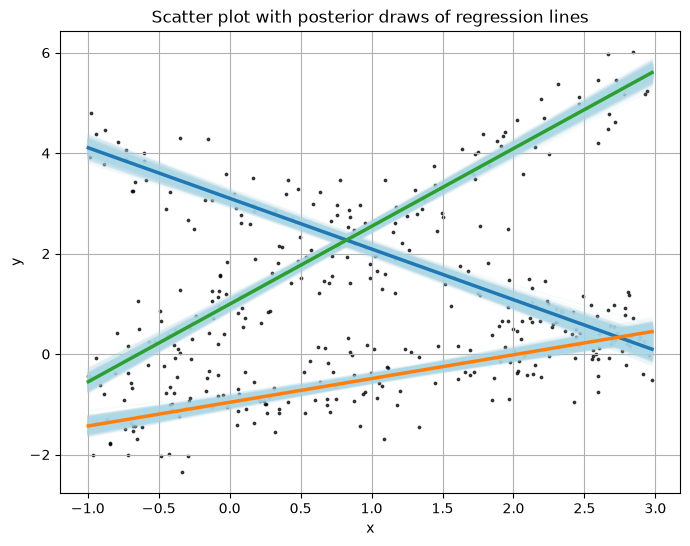

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=3, alpha=0.7, color='black')

xgrid = np.linspace(x.min(), x.max(), 200)
gamma_samples = out["gamma_samples"]

#Instead of plotting all the posterior samples, let us plot the most recent 500 samples:
k_plot = 500
idx = np.arange(len(gamma_samples) - k_plot, len(gamma_samples))

for t in idx:
    for j in range(3):
        plt.plot(
            xgrid,
            gamma_samples[t, j, 0] + gamma_samples[t, j, 1] * xgrid,
            alpha=0.08, color = 'lightblue'
        )

for j in range(3):
    plt.plot(
        xgrid,
        gamma_post_mean[j, 0] + gamma_post_mean[j, 1] * xgrid,
        linewidth=2.5,
        label=fr"posterior mean line {j+1}"
    )
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot with posterior draws of regression lines')
plt.grid(True)
plt.show()

In the plot below, we also show the true regression lines. 

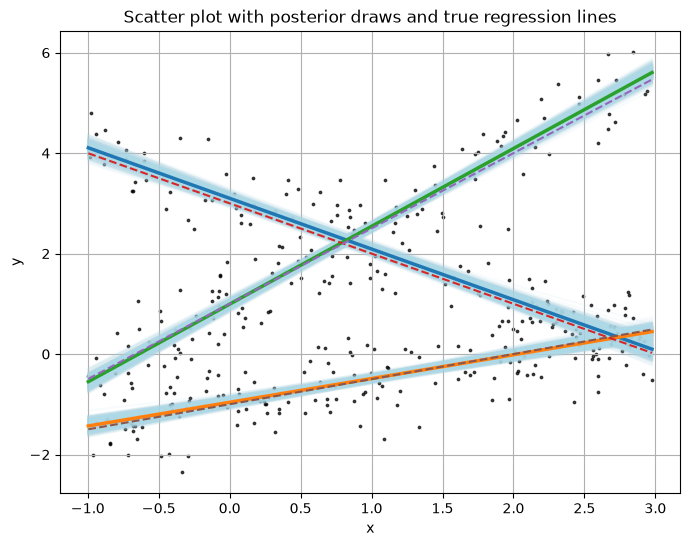

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=3, alpha=0.7, color='black')

xgrid = np.linspace(x.min(), x.max(), 200)
gamma_samples = out["gamma_samples"]

k_plot = 500
idx = np.arange(len(gamma_samples) - k_plot, len(gamma_samples))

for t in idx:
    for j in range(3):
        plt.plot(
            xgrid,
            gamma_samples[t, j, 0] + gamma_samples[t, j, 1] * xgrid,
            alpha=0.08, color='lightblue'
        )

for j in range(3):
    plt.plot(
        xgrid,
        gamma_post_mean[j, 0] + gamma_post_mean[j, 1] * xgrid,
        linewidth=2.5)

true_gammas = np.array([
    [3.0, -1.0],
    [1.0,  1.5],
    [-1.0, 0.5]
])

for j in range(3):
    plt.plot(
        xgrid,
        true_gammas[j, 0] + true_gammas[j, 1] * xgrid,
        linestyle='--',
        linewidth=1.5,
        )

plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot with posterior draws and true regression lines')
plt.grid(True)
plt.show()

Another advantage of the mixture of regression model is that we can also separate the data points into three points. Based on the posterior samples for $z_i$, we can calculate the posterior mode for $z_i$. Then the points can be separated into three groups $j = 1, 2, 3$ based on whether the posterior mode equals $j$. This is done below. 

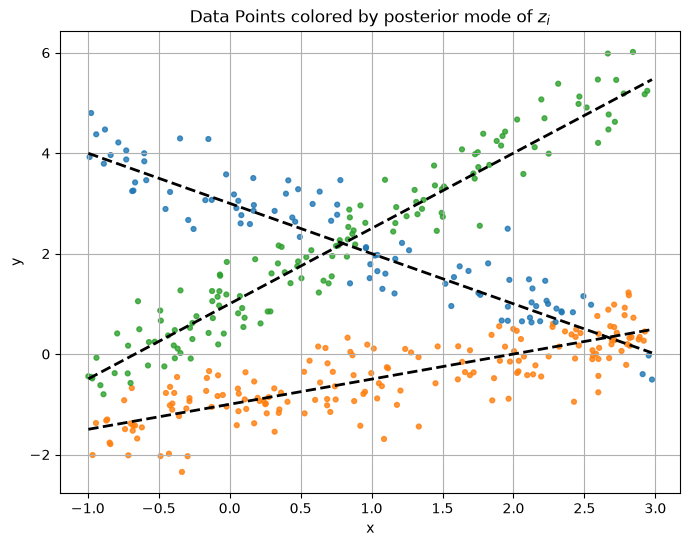

In [8]:
z_samples = out["z_samples"]   # shape: (n_saved, n)
z_mode = np.zeros(z_samples.shape[1], dtype=int)

for i in range(z_samples.shape[1]):
    z_mode[i] = np.bincount(z_samples[:, i], minlength=3).argmax()

colors = np.array(['tab:blue', 'tab:orange', 'tab:green'])
point_colors = colors[z_mode]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=12, c=point_colors, alpha=0.8)

xgrid = np.linspace(x.min(), x.max(), 200)

true_gammas = np.array([
    [3.0, -1.0],
    [1.0,  1.5],
    [-1.0, 0.5]
])

for j in range(3):
    plt.plot(
        xgrid,
        true_gammas[j, 0] + true_gammas[j, 1] * xgrid,
        linestyle='--',
        linewidth=2,
        color = 'black'
    )

plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Points colored by posterior mode of $z_i$')
plt.grid(True)
plt.show()

The mixture of regression model assumes that there are three groups that the population is made of. Each group corresponds to a different regression line. Given data (without any group information), the model can be used to divide the data into three groups, as shown above 